# Classificação de Attrition — versão de portfólio

## Origem do projeto

Este notebook moderniza, para fins de portfólio, um projeto colaborativo desenvolvido por um grupo de cinco trainees durante o Programa Trainee de Estatística da ICMC Júnior (2025.2). O grupo escolheu o desligamento de funcionários (attrition) como objetivo de Machine Learning. A V2 é uma evolução técnica posterior desse trabalho coletivo.

## Contexto e proveniência do dataset

O dataset HR Analytics utilizado neste projeto foi fornecido aos trainees como parte da atividade da ICMC Júnior. Os materiais originais do projeto descrevem os funcionários como pertencentes a uma empresa fictícia.

Essa proveniência no contexto da atividade não estabelece a origem externa da versão exata de `data/dados.csv`: o repositório não documenta seu criador original, a URL da fonte externa, a licença de redistribuição ou se o arquivo foi modificado antes de ser fornecido aos trainees.

## Definição do problema e escopo

A tarefa técnica é a classificação binária do rótulo registrado `Attrition` (`No` / `Yes`), no contexto de desligamento de funcionários. O dataset não documenta datas de observação ou de desligamento, um horizonte de previsão, nem se todas as features foram medidas antes do evento de desligamento. Portanto, esta análise não estabelece validade para previsão prospectiva de desligamentos em situações reais.

## Objetivo da V2

A V2 revisita o projeto com um protocolo de avaliação mais rigoroso: prevenção de vazamento de dados, pré-processamento dentro de pipelines, validação cruzada e seleção de modelos, hiperparâmetros e thresholds usando apenas o treinamento e sua evidência de validação / OOF. O modelo e o threshold finais são congelados antes da avaliação no holdout reservado, utilizado somente para estimar o desempenho de generalização. Os scores OOF usados na seleção não constituem uma estimativa independente desse desempenho.

# Etapa 1: Preparação dos dados e protocolo de avaliação

Nesta etapa definimos os conjuntos e o pré-processamento, sem ajustar transformadores ou treinar modelos.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1.1 Carregamento

O CSV está em `data/dados.csv`. O caminho abaixo funciona com o kernel iniciado na raiz do projeto ou na pasta `notebooks`. Nenhuma estatística é aprendida nesta leitura.

In [2]:
data_path = Path("data/dados.csv")
if not data_path.is_file():
    data_path = Path("../data/dados.csv")
if not data_path.is_file():
    raise FileNotFoundError("Execute a partir da raiz do projeto ou de notebooks: data/dados.csv não encontrado.")

df_raw = pd.read_csv(data_path)

#Legenda para as colunas:

* 'Age': Idade do funcionário.

* 'Attrition': Rótulo registrado de desligamento (No/Yes), sem horizonte de previsão documentado

* 'BusinessTravel': Indica a frequência com que o funcionário viaja a travalho

* 'DailyRate': Valor do salário por dia.

* 'Department': Departamento no qual o funcionário trabalha.

* 'DistanceFromHome': Distância em km/milhas da casa ao trabalho.

* 'Education': Nível de escolaridade

* 'EducationField': Área de formação.

* 'EmployeeCount': Coluna constante nos valores observados do projeto original (1), com ausências. Será removida; não deve ser preenchida usando Attrition.

* 'EmployeeNumber': Número de identificação do funcionário; será removido das features.

* 'EnvironmentSatisfaction': Satisfação com o ambiente de trabalho.

* 'Gender': Gênero do funcionário.

* 'HourlyRate': Valor do salário por hora. Observações: Verificar se é proprocional ou não a coluna 'DailyRate' (Valor do salário por dia). Caso haja algum tipo de proporção, basta excluir uma das colunas (informação redundante).

* 'JobInvolvement': Nível de engajamento com as tarefas.

* 'JobLevel': Nível do cargo.

* 'JobRole': Cargo/Função (Descrição do cargo)

* 'JobSatisfaction': Satisfação com o Trabalho (Nível de satisfação geral com o cargo).

* 'MaritalStatus': Estado Civil (Solteiro, Casado, Divorciado).

* 'MonthlyIncome': Renda Mensal (Salário bruto mensal).

* 'MonthlyRate': Valor/Taxa Mensal (Uma taxa interna da empresa, não é o salário).

* 'NumCompaniesWorked': Número de Empresas Anteriores (Quantas empresas o funcionário trabalhou antes desta).

* 'Over18': Acima de 18 Anos (Indica se o funcionário é maior de idade).

* 'OverTime': Horas Extras (Indica se o funcionário faz horas extras - Sim/Não).

* 'PercentSalaryHike': Aumento Percentual do Salário (Percentual do último aumento salarial).

* 'PerformanceRating': Avaliação de Desempenho (Nota da última avaliação de performance).

* 'RelationshipSatisfaction': Satisfação com Relacionamentos (Nível de satisfação com colegas e gestores).

* 'StandardHours': Horas Padrão (A carga horária padrão de trabalho, ex: 80 horas).

* 'StockOptionLevel': Nível de Opção de Ações (Nível do benefício de compra de ações da empresa).

* 'TotalWorkingYears': Total de Anos Trabalhados (Tempo total de experiência de carreira).

* 'TrainingTimesLastYear': Treinamentos no Último Ano (Número de treinamentos que participou no ano anterior).

* 'WorkLifeBalance': Equilíbrio Vida-Trabalho (Nível de satisfação com o equilíbrio entre vida pessoal e profissional).

* 'YearsAtCompany': Anos na Empresa (Tempo total de casa).

* 'YearsInCurrentRole': Anos no Cargo Atual (Tempo que está na função atual).

* 'YearsSinceLastPromotion': Anos Desde a Última Promoção.

* 'YearsWithCurrManager': Anos com o Gestor Atual.

## 1.2 Remoção de colunas previamente justificadas

Preservamos a decisão documentada no projeto original: remover `StandardHours` (80), `Over18` (Y), `EmployeeCount` (1 nos valores observados) e `EmployeeNumber` (identificador). A lista é fixa; não fazemos nova seleção de features usando a base completa.

In [3]:
columns_to_drop = ["StandardHours", "Over18", "EmployeeCount", "EmployeeNumber"]
df_features = df_raw.drop(columns=columns_to_drop)

## 1.3 Features e alvo

`X` contém apenas as features; `y` representa `Attrition`, com `No = 0` e `Yes = 1`. Validamos ausências e rótulos inesperados antes da conversão. Valores já codificados em 0/1 também são aceitos, sem modificar o alvo original.

In [4]:
X = df_features.drop(columns="Attrition").copy()
target = df_features["Attrition"]
if target.isna().any() or not target.isin(["No", "Yes", 0, 1]).all():
    raise ValueError("Attrition deve conter apenas No/Yes ou 0/1, sem valores ausentes.")
y = target.map({"No": 0, "Yes": 1, 0: 0, 1: 1}).astype("int64")

## 1.4 Separação imediata entre treino e teste

**Data leakage** ocorre quando informações indisponíveis ao treinamento, como as do teste, influenciam a preparação ou a escolha do modelo. Por isso, separamos os dados antes de aprender medianas, modas ou parâmetros de escala.

`stratify=y` preserva aproximadamente a proporção das classes em cada conjunto. O teste ficará reservado até a avaliação final, sem orientar análises exploratórias, imputação, hiperparâmetros ou limiares. Esta divisão organiza a V2; não torna a base inédita, pois ela já foi explorada no projeto original.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

### Inspeção inicial da base de treinamento

Recuperamos somente as linhas de treino em `df_raw`, pelos índices de `X_train`, para inspecionar também as colunas já removidas das features. Esta cópia é exclusivamente descritiva: não modifica `X_train`, não usa o teste e mantém as ausências.

O tamanho do treinamento, os tipos e a disponibilidade de valores ajudam a entender a estrutura dos registros antes das comparações descritivas.

In [6]:
df_train_raw = df_raw.loc[X_train.index].copy()
df_train_raw.info()
df_train_raw.head()

### Verificação das colunas removidas no treino

Confirmamos que `StandardHours`, `Over18` e `EmployeeCount` têm um único valor observado, desconsiderando ausências. Verificamos também a completude e a unicidade de `EmployeeNumber`, removido por ser identificador. A decisão de excluir as quatro colunas das features permanece; não preenchemos valores ausentes.

A tabela resume essas verificações: campos constantes não distinguem os registros pelos valores observados, enquanto EmployeeNumber identifica cada registro. Essas funções justificam a exclusão já definida, sem alterar as features selecionadas.

In [7]:
constant_columns = ["StandardHours", "Over18", "EmployeeCount"]
for column in constant_columns:
    observed_values = df_train_raw[column].dropna().unique()
    assert len(observed_values) == 1, f"{column} não é constante nos valores observados do treino."

assert df_train_raw["EmployeeNumber"].notna().all(), "Há identificadores ausentes no treino."
assert df_train_raw["EmployeeNumber"].is_unique, "Há identificadores repetidos no treino."

removed_columns_audit = pd.DataFrame({
    "Valores distintos observados": df_train_raw[columns_to_drop].nunique(dropna=True),
    "Valores ausentes": df_train_raw[columns_to_drop].isna().sum(),
})
removed_columns_audit

,Valores distintos observados,Valores ausentes
StandardHours,1,0
Over18,1,0
EmployeeCount,1,163
EmployeeNumber,1102,0


## 1.5 Tipos de features no treinamento

Identificamos as colunas somente em `X_train`. Nesta etapa, as escalas ordinais armazenadas como números continuam no grupo numérico.

In [8]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()

unsupported_features = set(X_train.columns) - set(numeric_features) - set(categorical_features)
if unsupported_features:
    raise ValueError(f"Tipos de features não tratados: {sorted(unsupported_features)}")

## 1.6 Fábrica de preprocessadores independentes

Cada chamada cria novos imputadores e transformadores. Numéricas recebem mediana e, com `scale_numeric=True`, padronização; categóricas recebem moda e one-hot encoding com categorias desconhecidas ignoradas. A função apenas constrói o preprocessador: suas estatísticas serão aprendidas posteriormente dentro de cada fold de treinamento, em um pipeline completo.

In [9]:
def make_preprocessor(numeric_features, categorical_features, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, list(numeric_features)),
        ("cat", categorical_pipeline, list(categorical_features)),
    ])

## 1.7 Validação cruzada no treino

A validação estratificada de cinco folds será usada posteriormente apenas com `X_train` e `y_train`. Cada fold ajustará seu próprio pipeline no subconjunto de treinamento e avaliará no de validação. Definir `cv` não treina nem avalia modelos.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 1.8 Base exclusiva para análise exploratória

As seções exploratórias existentes passam a usar `df`, uma cópia somente do treino. Mantemos os rótulos No/Yes nessa cópia para compatibilidade com os gráficos, sem alterar `y_train`. As ausências permanecem nos dados; nenhuma imputação é executada aqui.

In [11]:
df = X_train.copy()
df["Attrition"] = y_train.map({0: "No", 1: "Yes"})

### Ausências no treinamento

A tabela mostra a contagem e o percentual de valores ausentes em cada feature com ausências, usando o total de linhas de `X_train` como denominador. Features não listadas não têm ausências no treinamento. Essa informação explicita a disponibilidade dos dados para a descrição; nenhum valor é imputado aqui. O tratamento dos dados nos pipelines permanece separado desta inspeção.

In [12]:
missing_train = X_train.isna().sum()
missing_summary_train = pd.DataFrame({
    "missing_count": missing_train,
    "missing_percentage": missing_train / len(X_train) * 100,
})
missing_summary_train = missing_summary_train.loc[missing_summary_train["missing_count"] > 0]
missing_summary_train.index.name = "feature"
missing_summary_train.round({"missing_percentage": 2})

,missing_count,missing_percentage
feature,,
BusinessTravel,53,4.81
DistanceFromHome,41,3.72
EnvironmentSatisfaction,39,3.54
Gender,54,4.90
HourlyRate,24,2.18
JobInvolvement,47,4.26
OverTime,38,3.45
PerformanceRating,34,3.09


### Integridade da separação

Verificamos a ausência do alvo e das colunas removidas nas features, o alinhamento dos índices e a separação entre treino e teste. Estas verificações não ajustam transformadores nem avaliam modelos.

In [13]:
assert "Attrition" not in X.columns
assert not set(columns_to_drop).intersection(X.columns)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert X_train.index.intersection(X_test.index).empty
assert len(X_train) + len(X_test) == len(X)
assert df.index.equals(X_train.index)

A preparação termina com dados ainda não imputados e um protocolo de avaliação definido. As análises seguintes usam exclusivamente o treino; suas saídas antigas foram removidas para não representar a base completa como se fosse este novo subconjunto.

#Parte 2: Visualização e interpretação dos dados:

## 2.1 - Inspeção e distribuição do alvo

A inspeção anterior reúne o tamanho do treinamento, os tipos das features, as verificações de constantes e identificadores e a disponibilidade dos valores. Essas informações dão contexto às comparações selecionadas, sem exigir um catálogo de gráficos para cada variável. A seguir, a distribuição do alvo explicita o tamanho relativo das duas classes; as seções seguintes apresentam as associações categóricas e numéricas selecionadas.

### 2.1.1 - Distribuição de Attrition no treinamento

A distribuição do alvo abaixo usa somente `y_train` e apresenta contagens e percentuais. Attrition=Yes é a classe minoritária no treinamento, o que motiva examinar precision, recall e F1 da classe positiva nas etapas de avaliação. O desbalanceamento, isoladamente, não torna F1 a única métrica adequada.

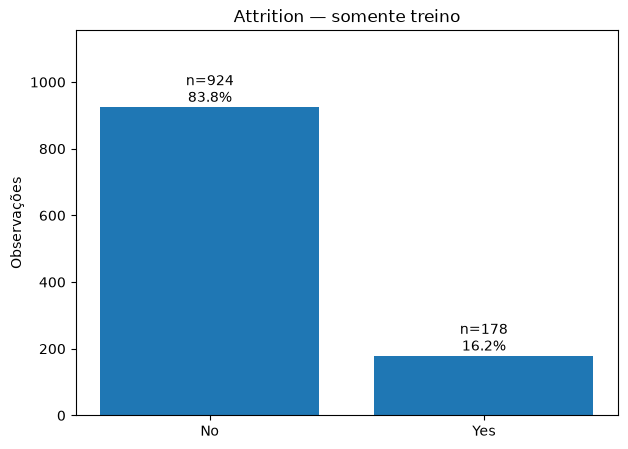

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 5), squeeze=False)

target_counts_train = y_train.value_counts().reindex([0, 1], fill_value=0)
target_percentages_train = target_counts_train / target_counts_train.sum()
target_bars = ax[0, 0].bar(["No", "Yes"], target_counts_train.to_numpy())
for bar, count, proportion in zip(target_bars, target_counts_train, target_percentages_train):
    ax[0, 0].annotate(
        f"n={count}\n{proportion:.1%}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4), textcoords="offset points", ha="center",
    )
ax[0, 0].set(title="Attrition — somente treino", ylabel="Observações", xlabel="")
ax[0, 0].set_ylim(0, target_counts_train.max() * 1.25)

## 2.2 - Associações exploratórias com Attrition

As comparações seguintes descrevem associações entre as features selecionadas e o rótulo Attrition no treinamento. Para as categóricas, examinamos taxas dentro de cada grupo, com seus tamanhos amostrais; para as numéricas, comparamos distribuições entre as classes. Essas diferenças não demonstram efeitos causais nem contribuição preditiva independente.

### 2.2.1 - Variáveis Categóricas

A comparação principal destaca OverTime, BusinessTravel e MaritalStatus. As barras representam a proporção observada de Attrition=Yes dentro de cada categoria, com o tamanho do grupo (`n`) e o número de saídas na tabela. Assim, grupos maiores não parecem ter maior taxa apenas por conterem mais observações.

Usamos exclusivamente as observações brutas de `X_train` e os rótulos alinhados de `y_train`. Ausências aparecem como `Missing`, quando presentes, sem imputação. As observações abaixo dos gráficos são geradas a partir dessas mesmas taxas; descrevem associações marginais no treinamento, sem controle por outras variáveis, interpretação causal ou garantia de generalização. Taxas de grupos pequenos devem ser lidas com cautela.

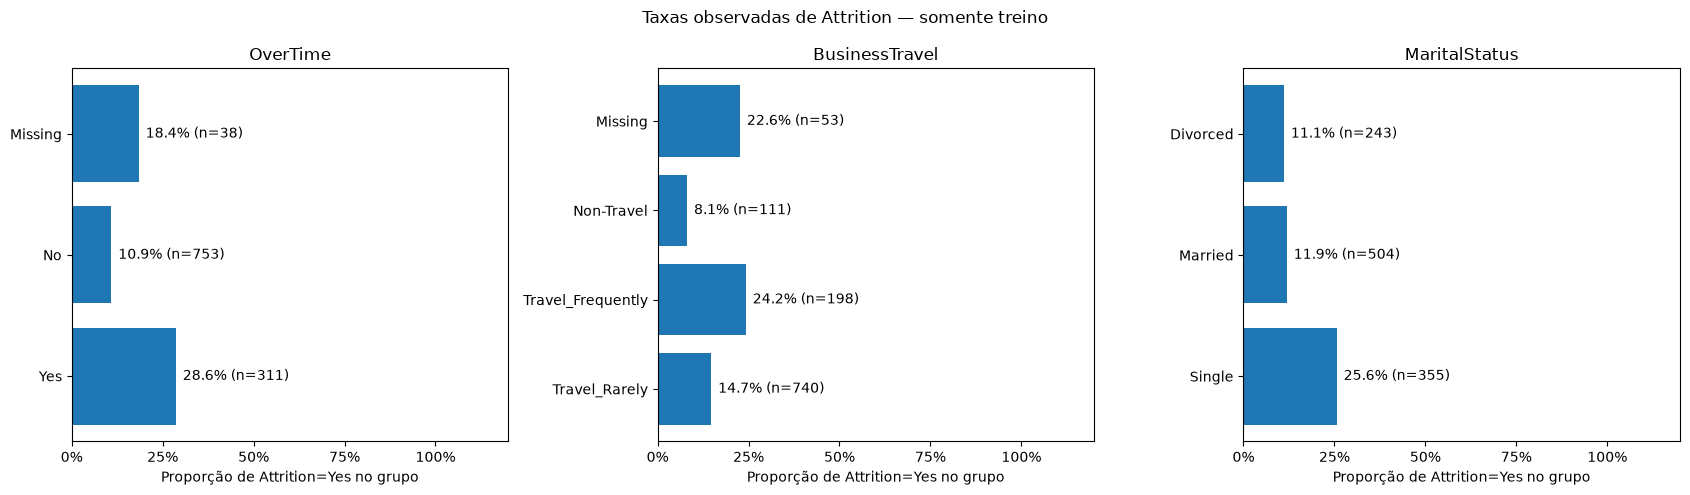


OverTime — somente treino
            n  yes_count attrition_rate
category                               
Missing    38          7         18.42%
No        753         82         10.89%
Yes       311         89         28.62%


**OverTime:** Maior taxa observada nesta amostra de treinamento: Yes.


BusinessTravel — somente treino
                     n  yes_count attrition_rate
category                                        
Missing             53         12         22.64%
Non-Travel         111          9          8.11%
Travel_Frequently  198         48         24.24%
Travel_Rarely      740        109         14.73%


**BusinessTravel:** Maior taxa observada nesta amostra de treinamento: Travel_Frequently.


MaritalStatus — somente treino
            n  yes_count attrition_rate
category                               
Divorced  243         27         11.11%
Married   504         60         11.90%
Single    355         91         25.63%


**MaritalStatus:** Maior taxa observada nesta amostra de treinamento: Single.

In [15]:
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

assert X_train.index.equals(y_train.index)
assert y_train.isin([0, 1]).all()
categorical_rates_train = {}
fig_categorical_rates, axes_categorical_rates = plt.subplots(1, 3, figsize=(17, 5))

for feature, rate_ax in zip(
    ["OverTime", "BusinessTravel", "MaritalStatus"], axes_categorical_rates
):
    raw_categories = X_train[feature].astype("object")
    categories = raw_categories.where(raw_categories.notna(), "Missing")
    descriptive_groups = pd.DataFrame({
        "category": categories,
        "attrition_yes": y_train,
    })
    rate_table = descriptive_groups.groupby("category", sort=True)["attrition_yes"].agg(
        n="size", yes_count="sum", attrition_rate="mean",
    )
    assert rate_table["n"].sum() == len(y_train)
    assert rate_table["yes_count"].sum() == y_train.sum()
    categorical_rates_train[feature] = rate_table

    rate_bars = rate_ax.barh(rate_table.index.astype(str), rate_table["attrition_rate"])
    for bar, group_n, rate in zip(rate_bars, rate_table["n"], rate_table["attrition_rate"]):
        rate_ax.annotate(
            f"{rate:.1%} (n={group_n})",
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0), textcoords="offset points", va="center",
        )
    rate_ax.set(title=feature, xlabel="Proporção de Attrition=Yes no grupo", xlim=(0, 1.2))
    rate_ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    rate_ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    rate_ax.invert_yaxis()

fig_categorical_rates.suptitle("Taxas observadas de Attrition — somente treino")
fig_categorical_rates.tight_layout()
plt.show()

for feature, rate_table in categorical_rates_train.items():
    print(f"\n{feature} — somente treino")
    print(rate_table.to_string(formatters={"attrition_rate": "{:.2%}".format}))
    if rate_table["attrition_rate"].nunique() > 1:
        highest_categories = ", ".join(
            rate_table.index[rate_table["attrition_rate"] == rate_table["attrition_rate"].max()].astype(str)
        )
        observation = f"Maior taxa observada nesta amostra de treinamento: {highest_categories}."
    else:
        observation = "As categorias apresentam a mesma taxa observada nesta amostra de treinamento."
    display(Markdown(f"**{feature}:** {observation}"))

### 2.2.2 - Variáveis Numéricas

A comparação principal usa Age, MonthlyIncome e YearsAtCompany nas observações brutas de treinamento. Os boxplots mostram a mediana, o intervalo interquartil e a dispersão; os bigodes alcançam os valores observados extremos dentro dos limites Q1−1,5×IQR e Q3+1,5×IQR. Pontos externos indicam potenciais outliers, não necessariamente erros nos dados.

A tabela apresenta, por feature e classe de Attrition, o tamanho total do grupo (`n`), o número de valores observados (`n_observed`), as ausências (`missing`), a média e a mediana. Ausências numéricas são excluídas explicitamente apenas do cálculo da respectiva feature e de seu gráfico, sem imputação ou exclusão global de linhas.

As interpretações são geradas a partir das medianas calculadas no treino. Estas são associações exploratórias não ajustadas: podem refletir relações entre idade, nível do cargo, renda e tempo de empresa. Não estabelecem causalidade, efeitos de intervenções, contribuição preditiva independente ou generalização para outras organizações.

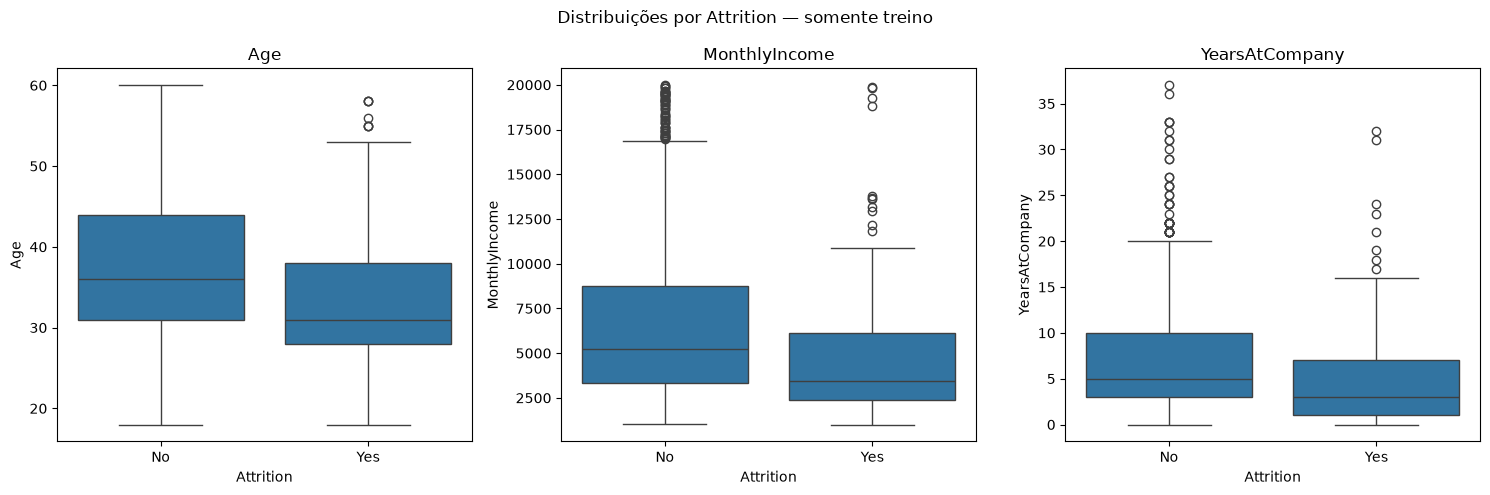

                            n  n_observed  missing     mean  median
feature        Attrition                                           
Age            No         924         924        0    37.66    36.0
               Yes        178         178        0    33.14    31.0
MonthlyIncome  No         924         924        0  6803.97  5209.5
               Yes        178         178        0  4897.21  3424.5
YearsAtCompany No         924         924        0     7.36     5.0
               Yes        178         178        0     4.83     3.0


**Age:** Na amostra de treinamento, as medianas são 36 para Attrition=No e 31 para Attrition=Yes. A mediana nas observações rotuladas Attrition=Yes é menor em relação à classe No.

**MonthlyIncome:** Na amostra de treinamento, as medianas são 5209.5 para Attrition=No e 3424.5 para Attrition=Yes. A mediana nas observações rotuladas Attrition=Yes é menor em relação à classe No.

**YearsAtCompany:** Na amostra de treinamento, as medianas são 5 para Attrition=No e 3 para Attrition=Yes. A mediana nas observações rotuladas Attrition=Yes é menor em relação à classe No.

In [16]:
from IPython.display import Markdown, display

assert X_train.index.equals(y_train.index)
assert y_train.isin([0, 1]).all()
numerical_eda_features = ["Age", "MonthlyIncome", "YearsAtCompany"]
numerical_eda_train = X_train[numerical_eda_features].copy()
numerical_eda_train["Attrition"] = y_train.map({0: "No", 1: "Yes"})
numerical_summary_rows = []
fig_numerical_attrition, axes_numerical_attrition = plt.subplots(1, 3, figsize=(15, 5))

for feature, numerical_ax in zip(numerical_eda_features, axes_numerical_attrition):
    for attrition_class in ["No", "Yes"]:
        group_values = numerical_eda_train.loc[
            numerical_eda_train["Attrition"] == attrition_class, feature
        ]
        observed_values = group_values.dropna()
        numerical_summary_rows.append({
            "feature": feature,
            "Attrition": attrition_class,
            "n": len(group_values),
            "n_observed": len(observed_values),
            "missing": int(group_values.isna().sum()),
            "mean": observed_values.mean(),
            "median": observed_values.median(),
        })
    plot_values = numerical_eda_train[["Attrition", feature]].dropna(subset=[feature])
    sns.boxplot(
        data=plot_values, x="Attrition", y=feature, order=["No", "Yes"],
        whis=1.5, showfliers=True, ax=numerical_ax,
    )
    numerical_ax.set(title=feature, xlabel="Attrition", ylabel=feature)

fig_numerical_attrition.suptitle("Distribuições por Attrition — somente treino")
fig_numerical_attrition.tight_layout()
plt.show()

numerical_summary_train = pd.DataFrame(numerical_summary_rows).set_index(["feature", "Attrition"])
assert (numerical_summary_train["n_observed"] + numerical_summary_train["missing"] == numerical_summary_train["n"]).all()
print(numerical_summary_train.round(2).to_string())

for feature in numerical_eda_features:
    median_no = numerical_summary_train.loc[(feature, "No"), "median"]
    median_yes = numerical_summary_train.loc[(feature, "Yes"), "median"]
    if pd.isna(median_no) or pd.isna(median_yes):
        interpretation = "Não há valores observados suficientes em ambas as classes para comparar as medianas."
    else:
        comparison = "menor" if median_yes < median_no else "maior" if median_yes > median_no else "igual"
        interpretation = (
            f"Na amostra de treinamento, as medianas são {median_no:g} para Attrition=No "
            f"e {median_yes:g} para Attrition=Yes. A mediana nas observações rotuladas "
            f"Attrition=Yes é {comparison} em relação à classe No."
        )
    display(Markdown(f"**{feature}:** {interpretation}"))

# Parte 3: Análise de correlação no treino

Esta análise usa apenas `df`, derivado de `X_train`. Na codificação exploratória, ausências categóricas recebem indicadores (`dummy_na=True`); ausências numéricas permanecem e as correlações usam pares disponíveis. Não há imputação nem exclusão global de linhas. Essa codificação é apenas para exploração e não alimenta os modelos.

### Correlação entre MonthlyRate, HourlyRate e DailyRate no treino

Retomamos a hipótese exploratória de que essas taxas poderiam conter informação linear redundante. A matriz de Pearson e o heatmap usam somente `X_train`, com pares de valores disponíveis: não há imputação nem exclusão global de linhas.

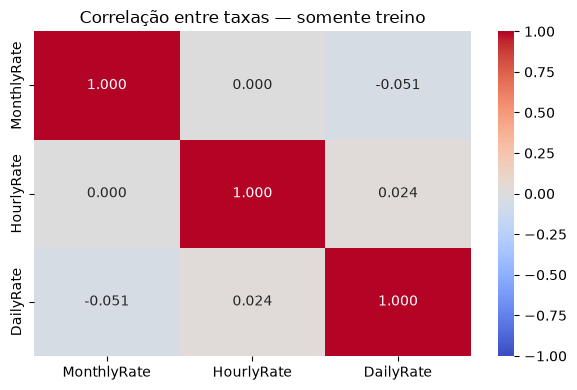

In [17]:
rate_columns = ["MonthlyRate", "HourlyRate", "DailyRate"]
rate_correlation = X_train[rate_columns].corr(method="pearson")

fig_rates, ax_rates = plt.subplots(figsize=(6, 4))
sns.heatmap(
    rate_correlation, annot=True, cmap="coolwarm", fmt=".3f",
    vmin=-1, vmax=1, center=0, ax=ax_rates,
)
ax_rates.set_title("Correlação entre taxas — somente treino")
fig_rates.tight_layout()
plt.show()

Os coeficientes apresentados no heatmap são próximos de zero e não sustentam a hipótese de forte redundância linear entre essas taxas no treinamento. As três features permanecem na análise. Isso não demonstra ausência de relações não lineares nem garante utilidade preditiva.

Pearson resume associação linear; Spearman resume associação monotônica entre postos. Examinar ambos permite comparar essas duas perspectivas sobre as relações entre features, sem interpretar concordância como evidência causal.

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

#Funções Auxiliares

def filter_correlation_matrix(corr_matrix, prefixes):
    matrix_filtrada = corr_matrix.copy()
    for prefix in prefixes:
        cols_com_prefixo = [col for col in matrix_filtrada.columns if col.startswith(prefix)]
        if len(cols_com_prefixo) > 1:
            for var1, var2 in combinations(cols_com_prefixo, 2):
                matrix_filtrada.loc[var1, var2] = np.nan
                matrix_filtrada.loc[var2, var1] = np.nan
    return matrix_filtrada

def select_top_correlation_pairs(filtered_matrix, n=10):
    upper_triangle = np.triu(np.ones(filtered_matrix.shape, dtype=bool), k=1)
    unique_pairs = filtered_matrix.where(upper_triangle).unstack().dropna()
    ranked_indices = unique_pairs.abs().sort_values(
        ascending=False, kind="stable"
    ).head(n).index
    return unique_pairs.loc[ranked_indices]

def print_top_10(filtered_matrix, method_name):
    top_10_final = select_top_correlation_pairs(filtered_matrix)

    df_top_10 = (
        top_10_final
        .to_frame(name='Correlacao')
        .reset_index()
        .rename(columns={'level_0': 'Variável 1', 'level_1': 'Variável 2'})
    )

    print(f"\n--- Top 10 Correlações ({method_name.upper()}) ---")
    print(df_top_10.to_string(index=False))
    print("-" * 70)

cols_object = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

prefixes = [col + '_' for col in cols_object]

df_encoded = df.pipe(pd.get_dummies, columns=cols_object, drop_first=False, dummy_na=True)


As tabelas apresentam os dez pares com maior magnitude de correlação em cada método, preservando o sinal dos coeficientes. A seleção usa pares únicos e mantém o filtro já definido entre categorias da mesma feature. O valor do coeficiente, e não apenas sua posição no ranking, orienta a leitura da magnitude da associação.

In [19]:
matriz_corr_pearson = df_encoded.corr(method='pearson')
matriz_pearson_filtrada = filter_correlation_matrix(matriz_corr_pearson, prefixes)
print_top_10(matriz_pearson_filtrada, 'pearson')


--- Top 10 Correlações (PEARSON) ---
             Variável 1                        Variável 2  Correlacao
          MonthlyIncome                          JobLevel    0.946542
JobRole_Human Resources        Department_Human Resources    0.915909
JobRole_Sales Executive                  Department_Sales    0.825612
      TotalWorkingYears                          JobLevel    0.782898
      TotalWorkingYears                     MonthlyIncome    0.770377
   YearsWithCurrManager                    YearsAtCompany    0.770317
      PerformanceRating                 PercentSalaryHike    0.769263
     YearsInCurrentRole                    YearsAtCompany    0.767113
JobRole_Sales Executive Department_Research & Development   -0.752606
   YearsWithCurrManager                YearsInCurrentRole    0.715179
----------------------------------------------------------------------


In [20]:
matriz_corr_spearman = df_encoded.corr(method='spearman')
matriz_spearman_filtrada = filter_correlation_matrix(matriz_corr_spearman, prefixes)
print_top_10(matriz_spearman_filtrada, 'spearman')


--- Top 10 Correlações (SPEARMAN) ---
             Variável 1                        Variável 2  Correlacao
          MonthlyIncome                          JobLevel    0.920414
JobRole_Human Resources        Department_Human Resources    0.915909
     YearsInCurrentRole                    YearsAtCompany    0.852429
   YearsWithCurrManager                    YearsAtCompany    0.845409
JobRole_Sales Executive                  Department_Sales    0.825612
JobRole_Sales Executive Department_Research & Development   -0.752606
      TotalWorkingYears                          JobLevel    0.736331
   MaritalStatus_Single                  StockOptionLevel   -0.733987
   YearsWithCurrManager                YearsInCurrentRole    0.731030
      TotalWorkingYears                     MonthlyIncome    0.712539
----------------------------------------------------------------------


A interseção abaixo identifica pares presentes entre as dez maiores magnitudes em ambos os métodos. Os respectivos coeficientes estão nas tabelas anteriores; aparecer nos dois rankings não implica, por si só, associação de grande magnitude.

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

def get_top_10_pairs(corr_matrix, prefixes):
    """Retorna os pares únicos com maior magnitude de correlação após o filtro."""
    matrix_filtrada = filter_correlation_matrix(corr_matrix, prefixes)
    top_pairs = select_top_correlation_pairs(matrix_filtrada)
    return {tuple(sorted(pair)) for pair in top_pairs.index}


cols_object = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
prefixes = [col + '_' for col in cols_object]
df_encoded = df.pipe(pd.get_dummies, columns=cols_object, drop_first=False, dummy_na=True)

#Obter pares do Pearson
matriz_corr_pearson = df_encoded.corr(method='pearson')
pares_pearson = get_top_10_pairs(matriz_corr_pearson, prefixes)

#Obter pares do Spearman
matriz_corr_spearman = df_encoded.corr(method='spearman')
pares_spearman = get_top_10_pairs(matriz_corr_spearman, prefixes)

#Intersecção
pares_em_comum = pares_pearson.intersection(pares_spearman)

print("Pares Comuns no Top 10 (Pearson & Spearman):")
print(f"Total de pares encontrados: {len(pares_em_comum)}")

if not pares_em_comum:
    print("Nenhum par em comum encontrado.")
else:
    for i, (var1, var2) in enumerate(pares_em_comum):
        print(f"  {i+1}. {var1}  <-->  {var2}")

A concordância entre os rankings descreve esta amostra de treinamento, sem estabelecer causalidade, progressão temporal ou generalização para outras empresas. As correlações numéricas usam pares disponíveis, de modo que a quantidade de observações pode variar entre pares.

### Síntese da EDA

A distribuição do treinamento evidencia a classe minoritária Attrition=Yes e dá contexto às comparações por grupo. As taxas de OverTime, BusinessTravel e MaritalStatus são acompanhadas dos tamanhos amostrais; os boxplots e resumos de Age, MonthlyIncome e YearsAtCompany permitem examinar diferenças de distribuição entre os rótulos. As tabelas de Pearson e Spearman complementam essa leitura com as magnitudes e os sinais das associações entre features.

Essas associações são exploratórias e não ajustadas, não efeitos causais. Características relacionadas, como idade, nível do cargo, renda e tempo de empresa, dificultam interpretações isoladas. A utilidade preditiva é avaliada no fluxo de validação e modelagem a seguir, não estabelecida pela EDA; os resultados não devem ser extrapolados para outras empresas sem avaliação apropriada.

# Parte 4: Comparação inicial por validação cruzada

Esta etapa é **model selection**: comparamos cinco configurações fixas exclusivamente em `X_train` e `y_train`, usando o `StratifiedKFold` já definido. Não fazemos tuning, ajuste de threshold ou escolha de vencedor.

`X_test` e `y_test` continuam reservados. O teste final ocorrerá somente depois da escolha do modelo e das decisões de tuning/threshold, sem orientar essas decisões. Os resultados históricos foram substituídos por esta avaliação; os scores dos folds são de validação, não do teste reservado.

## 4.1 Modelos e referências de comparação

**DummyClassifier:** prevê sempre a classe mais frequente do treinamento de cada fold. É a referência trivial para medir quanto uma accuracy elevada pode refletir apenas o desbalanceamento.

**Regressão Logística:** referência simples, eficiente e adequada à classificação binária. Modela uma combinação linear das features transformadas na escala de log-odds. A padronização auxilia a otimização e a regularização. Sua simplicidade e interpretabilidade devem ser consideradas junto com o desempenho, pelo princípio de parcimônia.

**Random Forest:** combina árvores com aleatoriedade nas amostras e nas features. Pode capturar interações e relações não lineares. Maior complexidade não garante melhor desempenho na classe positiva.

**Gradient Boosting:** constrói árvores sequencialmente, buscando reduzir os erros segundo a função de perda. Sua adequação a dados tabulares é uma motivação para experimentá-lo, não uma garantia de superioridade.

**XGBoost:** outra implementação de boosting de árvores. `scale_pos_weight` pondera a contribuição da classe positiva à perda; não reamostra os dados nem garante aumento de recall. Comparar GBM com XGBoost altera simultaneamente o algoritmo e a ponderação, portanto diferenças observadas não podem ser atribuídas apenas ao peso das classes.

In [22]:
import platform
import numpy as np
import pandas as pd
import sklearn
import xgboost

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
)
from xgboost import XGBClassifier

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
})

{'python': '3.11.14', 'numpy': '2.4.6', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'xgboost': '3.2.0'}


## 4.2 Configurações fixas e pipelines independentes

Cada modelo recebe uma nova instância de `make_preprocessor`. Apenas a Regressão Logística usa escala; Dummy e árvores usam imputação e one-hot encoding sem `StandardScaler`.

O peso do XGBoost é `n_negativos / n_positivos`, calculado uma única vez com `y_train` e mantido fixo nos folds, conforme este protocolo. Isso usa a distribuição dos rótulos de todo o treino, incluindo as parcelas de validação interna; não é um peso reestimado no treinamento de cada fold. Já `class_weight="balanced"` da Regressão Logística e da Random Forest é calculado pelo estimador a cada ajuste. Nenhum desses pesos utiliza o teste reservado.

A validação cruzada clonará os pipelines: imputadores, encoder e escala serão ajustados somente no treinamento do fold. `n_jobs=1` limita a execução a um processo de validação e uma thread no XGBoost; não representa tuning.

In [23]:
assert not y_train.isna().any()
assert set(y_train.unique()) == {0, 1}
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_configs = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=42,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", n_jobs=1,
    ),
}

model_pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", make_preprocessor(
            numeric_features, categorical_features,
            scale_numeric=(name == "Logistic Regression"),
        )),
        ("classifier", classifier),
    ])
    for name, classifier in model_configs.items()
}
print(f"scale_pos_weight calculado com y_train: {scale_pos_weight:.6f}")

## 4.3 Métricas

A classe positiva é **1 / Attrition Yes**. Accuracy mede os acertos globais; precision mede a fração de alertas positivos corretos; recall mede a fração de saídas detectadas; F1 é a média harmônica de precision e recall da classe positiva.

ROC-AUC e Average Precision avaliam os scores de probabilidade sem escolher um novo limiar. Average Precision resume a curva precision-recall e deve ser interpretada considerando a prevalência positiva. Em classificação binária com rótulos 0/1, o scorer de ROC-AUC usa a probabilidade da classe 1.

Os scorers de precision, recall e F1 usam `average="binary"`, `pos_label=1` e `zero_division=0`. Assim, a precision do Dummy é registrada como zero quando ele não prevê positivos. Usamos as decisões padrão de `predict`, sem ajustar threshold.

In [24]:
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(
        precision_score, average="binary", pos_label=1, zero_division=0,
    ),
    "recall": make_scorer(
        recall_score, average="binary", pos_label=1, zero_division=0,
    ),
    "f1": make_scorer(
        f1_score, average="binary", pos_label=1, zero_division=0,
    ),
    "roc_auc": make_scorer(roc_auc_score, response_method="predict_proba"),
    "average_precision": make_scorer(
        average_precision_score, response_method="predict_proba", pos_label=1,
    ),
}

## 4.4 Execução da validação cruzada

Reutilizamos `cv`, com cinco folds estratificados, embaralhamento e semente 42. As divisões são as mesmas para todos os modelos. Cada chamada ajusta cinco clones do pipeline; não há ajuste final em todo o treino nesta etapa. Erros interrompem a execução em vez de serem convertidos silenciosamente em scores ausentes.

In [25]:
cv_results = {}
fold_records = []

for model_name, pipeline in model_pipelines.items():
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        n_jobs=1, return_train_score=False, error_score="raise",
    )
    cv_results[model_name] = scores
    for fold in range(cv.get_n_splits()):
        fold_records.append({
            "model": model_name,
            "fold": fold + 1,
            **{metric: scores[f"test_{metric}"][fold] for metric in scoring},
        })
    print(f"{model_name}: {cv.get_n_splits()} folds concluídos")

fold_results = pd.DataFrame(fold_records)

## 4.5 Tabela comparativa

`cv_summary` contém média e desvio padrão amostral (`ddof=1`) de cada métrica nos cinco folds, sem ordenar os modelos como um ranking. O desvio padrão descreve a variação entre folds; não é um intervalo de confiança nem comprova significância de diferenças.

As chaves `test_*` retornadas pela API `cross_validate` significam **validação interna do fold**, não acesso ao conjunto de teste reservado.

In [26]:
cv_summary = (
    fold_results.groupby("model", sort=False)[list(scoring)]
    .agg(["mean", "std"])
    .reindex(model_pipelines)
)
cv_summary.columns = [
    f"{metric}_{statistic}" for metric, statistic in cv_summary.columns
]
cv_summary.round(4)

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
model,,,,,,,,,,,,
Dummy,0.8385,0.0022,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.1615,0.0022
Logistic Regression,0.7750,0.0258,0.3968,0.0362,0.7529,0.0921,0.5190,0.0498,0.8374,0.0535,0.6273,0.1154
Random Forest,0.8602,0.0199,0.6330,0.1100,0.3592,0.0510,0.4538,0.0560,0.7916,0.0427,0.5337,0.0464
Gradient Boosting,0.8748,0.0091,0.7806,0.0968,0.3143,0.0330,0.4475,0.0457,0.8180,0.0287,0.5727,0.0392
XGBoost,0.8593,0.0153,0.5967,0.0695,0.3875,0.0970,0.4663,0.0881,0.8025,0.0295,0.5509,0.0542


## 4.6 Interpretação dos trade-offs

A leitura abaixo usa as médias efetivamente calculadas. Accuracy deve ser confrontada com o Dummy e com as métricas da classe positiva. Precision e recall descrevem compromissos diferentes: mais alertas podem recuperar mais saídas e também gerar falsos positivos. Os pesos de classe não garantem o mesmo compromisso entre algoritmos.

Nesta execução, a Regressão Logística apresentou recall médio de 0.753 e precision média de 0.397, enquanto o Gradient Boosting apresentou recall de 0.314 e precision de 0.781. A primeira configuração recupera uma fração maior das saídas observadas, mas uma fração menor dos seus alertas positivos está correta. A segunda gera alertas mais precisos, mas deixa de detectar uma fração maior das saídas. A Random Forest, mesmo com ponderação de classes, teve recall médio de 0.359: o uso de pesos não assegura alta detecção da classe minoritária. Essas observações não estabelecem um vencedor.

In [27]:
positive_rate = y_train.mean()
print(f"Prevalência de Attrition Yes no treino: {positive_rate:.2%}.")
dummy_scores = cv_summary.loc["Dummy"]
print(
    f"Dummy: accuracy média {dummy_scores['accuracy_mean']:.3f}, "
    f"recall positivo {dummy_scores['recall_mean']:.3f} e "
    f"F1 positivo {dummy_scores['f1_mean']:.3f}. "
    "A accuracy elevada da referência majoritária não significa detecção de saídas."
)
for model_name in model_pipelines:
    if model_name == "Dummy":
        continue
    values = cv_summary.loc[model_name]
    print(
        f"{model_name}: precision {values['precision_mean']:.3f}, "
        f"recall {values['recall_mean']:.3f}, F1 {values['f1_mean']:.3f}; "
        f"accuracy {values['accuracy_mean']:.3f} "
        f"(diferença para Dummy: {values['accuracy_mean'] - dummy_scores['accuracy_mean']:+.3f}); "
        f"ROC-AUC {values['roc_auc_mean']:.3f}, "
        f"Average Precision {values['average_precision_mean']:.3f}."
    )

## 4.7 Limites e próximas decisões

Esta comparação é exploratória e não declara um modelo vencedor. Os scores de validação usados para seleção não substituem uma avaliação final independente. Diferenças entre configurações devem ser consideradas junto com a variação entre folds, a simplicidade e os custos de falsos positivos e falsos negativos.

Em etapas posteriores serão definidas a escolha do modelo e eventuais decisões de tuning/threshold usando somente o treinamento e sua validação interna. Apenas depois dessas decisões o pipeline escolhido poderá ser ajustado em todo o treino e avaliado uma vez em `X_test` e `y_test`. O teste reservado não foi usado nesta Parte 4.

Para reprodução, as versões de Python e das bibliotecas desta execução estão registradas na saída da célula de imports. No macOS, o XGBoost também requer o runtime OpenMP (`libomp`). O notebook não instala dependências automaticamente.

# Parte 5: Tuning dos modelos candidatos

**Hyperparameter tuning** é a comparação de configurações que controlam o aprendizado, como regularização, quantidade e profundidade das árvores. Cada configuração será ajustada nos folds de treinamento e pontuada nos folds de validação do `cv` já definido, sempre dentro de `X_train` e `y_train`.

O objetivo principal é **F1 da classe positiva (1 / Attrition Yes)**: uma média harmônica de precision e recall que considera tanto alertas incorretos quanto saídas não detectadas. Accuracy pode ser elevada apenas pela classe majoritária. F1 não representa diretamente custos de negócio e não substitui a leitura das outras métricas.

O tuning usa validação, não o teste: consultar `X_test` ou `y_test` para escolher hiperparâmetros contaminaria a avaliação final. Ambos continuam reservados. Não ajustamos threshold nem fazemos avaliação final nesta etapa. Random Forest e Dummy permanecem no benchmark da Parte 4.

In [28]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, ParameterGrid
from sklearn.metrics import make_scorer, f1_score

candidate_names = ["Logistic Regression", "Gradient Boosting", "XGBoost"]
tuning_scoring = dict(scoring)
tuning_scoring["f1"] = make_scorer(
    f1_score, average="binary", pos_label=1, zero_division=0,
)

tuning_pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", make_preprocessor(
            numeric_features, categorical_features,
            scale_numeric=(name == "Logistic Regression"),
        )),
        ("classifier", clone(model_configs[name])),
    ])
    for name in candidate_names
}

## 5.1 Espaços de busca e orçamento

- **Regressão Logística — 12 combinações:** `C` em 0.1, 1 e 10 cobre três intensidades de regularização; pesos sem ponderação ou balanceados; `lbfgs` e `liblinear`, ambos compatíveis com a regularização L2 padrão e a classificação binária. Mantemos `max_iter=1000` e semente 42.
- **Gradient Boosting — 8 combinações:** 100 ou 200 árvores, taxas 0.05 ou 0.1 e profundidades 1 ou 3. A grade compara árvores simples com interações mais complexas e diferentes velocidades de aprendizado.
- **XGBoost — 12 amostras dentre 48 combinações:** 100 ou 200 árvores, taxas 0.05 ou 0.1, profundidades 2 ou 4, frações de amostragem 0.8 ou 1.0 e três pesos positivos. A busca aleatória usa semente 42, sem reposição entre essas combinações discretas.

O peso de referência do XGBoost é calculado somente com `y_train`; avaliamos 1, metade dessa razão e a razão completa. Esses valores são fixos durante a busca, usando a distribuição de todo o treino, incluindo suas parcelas de validação interna. Imputadores, encoder, escala e pesos automáticos de `class_weight="balanced"` são aprendidos em cada ajuste do fold.

São **32 configurações × 5 folds = 160 fits**. Cada candidato recebe seu próprio pipeline e preprocessor. A execução usa `n_jobs=1`, e `refit=False` evita três ajustes adicionais em todo o treino.

In [29]:
tuning_weight_ratio = float((y_train == 0).sum() / (y_train == 1).sum())

logistic_grid = {
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["lbfgs", "liblinear"],
}
gradient_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [1, 3],
}
xgboost_space = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 4],
    "classifier__subsample": [0.8, 1.0],
    "classifier__scale_pos_weight": [1.0, tuning_weight_ratio / 2, tuning_weight_ratio],
}

search_options = dict(
    scoring=tuning_scoring, cv=cv, refit=False,
    n_jobs=1, return_train_score=False, error_score="raise",
)
tuning_searches = {
    "Logistic Regression": GridSearchCV(
        tuning_pipelines["Logistic Regression"], logistic_grid, **search_options,
    ),
    "Gradient Boosting": GridSearchCV(
        tuning_pipelines["Gradient Boosting"], gradient_grid, **search_options,
    ),
    "XGBoost": RandomizedSearchCV(
        tuning_pipelines["XGBoost"], xgboost_space,
        n_iter=12, random_state=42, **search_options,
    ),
}
planned_candidates = {
    "Logistic Regression": len(ParameterGrid(logistic_grid)),
    "Gradient Boosting": len(ParameterGrid(gradient_grid)),
    "XGBoost": 12,
}
planned_fits = sum(planned_candidates.values()) * cv.get_n_splits()
print(f"Configurações por modelo: {planned_candidates}; fits planejados: {planned_fits}.")

## 5.2 Execução e seleção de uma configuração por candidato

Os mesmos cinco folds são reutilizados para todas as configurações. Selecionamos a linha com maior **média de F1 positivo** em cada busca; em empate exato, mantemos a primeira configuração na ordem reproduzível da busca. Não há escolha automática de um vencedor entre algoritmos.

Como usamos múltiplas métricas e `refit=False`, extraímos explicitamente a configuração escolhida de `cv_results_`. Precision, recall, ROC-AUC e Average Precision vêm dessa mesma linha, não dos máximos individuais de cada métrica. Recalculamos os desvios padrão dos scores dos cinco folds com `ddof=1`, igual ao benchmark. Os campos `test_*` da API representam validação interna, não o teste reservado.

In [30]:
tuning_rows = []
best_parameters = {}
best_candidate_indices = {}
best_fold_scores = {}
search_results = {}
executed_search_fits = 0

for model_name, search in tuning_searches.items():
    search.fit(X_train, y_train)
    results = search.cv_results_
    search_results[model_name] = pd.DataFrame(results)
    best_index = int(np.argmax(results["mean_test_f1"]))
    best_candidate_indices[model_name] = best_index
    best_parameters[model_name] = results["params"][best_index]

    selected_folds = pd.DataFrame({
        metric: [
            results[f"split{fold}_test_{metric}"][best_index]
            for fold in range(cv.get_n_splits())
        ]
        for metric in tuning_scoring
    })
    best_fold_scores[model_name] = selected_folds
    row = {"model": model_name}
    for metric in tuning_scoring:
        row[f"{metric}_mean"] = float(selected_folds[metric].mean())
        row[f"{metric}_std"] = float(selected_folds[metric].std(ddof=1))
    tuning_rows.append(row)

    candidate_count = len(results["params"])
    fit_count = candidate_count * cv.get_n_splits()
    executed_search_fits += fit_count
    print(f"{model_name}: {candidate_count} configurações, {fit_count} fits nos folds.")

tuning_summary = pd.DataFrame(tuning_rows).set_index("model")
print(f"Total: {executed_search_fits} fits de busca; nenhum refit em todo o treino.")

## 5.3 Melhores hiperparâmetros por F1 de validação

São as configurações selecionadas dentro dos espaços e do orçamento definidos acima. Isso não significa ótimo global nem resultado de teste final. Parâmetros não listados continuam com a configuração de referência da Parte 4.

In [31]:
best_params_table = pd.DataFrame([
    {"model": name, "parameter": parameter.removeprefix("classifier__"), "value": value}
    for name in candidate_names
    for parameter, value in best_parameters[name].items()
])
best_params_table

,model,parameter,value
0,Logistic Regression,C,10.0
1,Logistic Regression,class_weight,None
2,Logistic Regression,solver,lbfgs
3,Gradient Boosting,learning_rate,0.1
4,Gradient Boosting,max_depth,3
5,Gradient Boosting,n_estimators,200
6,XGBoost,subsample,0.8
7,XGBoost,scale_pos_weight,2.595506
8,XGBoost,n_estimators,200
9,XGBoost,max_depth,2


## 5.4 Benchmark inicial versus tuning

Aqui, **benchmark original** significa a comparação válida por cross-validation da Parte 4, não os resultados históricos do projeto trainee. Reutilizamos `cv_summary` dessa execução, sem refazer o benchmark ou acessar o teste reservado. As seis linhas comparam a referência e o tuning para os três candidatos, mantendo os nomes dos modelos sem ordená-los como ranking.

Os resultados escolhidos na busca tendem a ser otimistas, pois os mesmos folds orientaram a seleção. Esta comparação não é uma avaliação independente nem uma validação cruzada aninhada. Desvios padrão entre folds descrevem variabilidade, não significância estatística.

In [32]:
comparison_columns = [
    "accuracy_mean", "f1_mean", "f1_std", "precision_mean", "recall_mean",
    "roc_auc_mean", "average_precision_mean",
]
comparison_rows = []
for model_name in candidate_names:
    for stage, table in [("Benchmark", cv_summary), ("Tuning", tuning_summary)]:
        comparison_rows.append({
            "model": model_name,
            "stage": stage,
            **{column: table.loc[model_name, column] for column in comparison_columns},
        })
benchmark_vs_tuning = pd.DataFrame(comparison_rows).set_index(["model", "stage"])
with pd.option_context("display.max_columns", None, "display.width", 180):
    print(benchmark_vs_tuning.round(4).to_string())

                               accuracy_mean  f1_mean  f1_std  precision_mean  recall_mean  roc_auc_mean  average_precision_mean
model               stage                                                                                                       
Logistic Regression Benchmark         0.7750   0.5190  0.0498          0.3968       0.7529        0.8374                  0.6273
                    Tuning            0.8802   0.5523  0.1546          0.6960       0.4608        0.8463                  0.6456
Gradient Boosting   Benchmark         0.8748   0.4475  0.0457          0.7806       0.3143        0.8180                  0.5727
                    Tuning            0.8702   0.4657  0.0697          0.6909       0.3535        0.8197                  0.5778
XGBoost             Benchmark         0.8593   0.4663  0.0881          0.5967       0.3875        0.8025                  0.5509
                    Tuning            0.8738   0.5544  0.0762          0.6443       0.4887       

## 5.5 Interpretação dos compromissos

Comparamos alterações em precision, recall e F1 em conjunto. Aumentar F1 pode envolver ganho de precision com perda de recall, ou o inverso. O critério de busca escolhe uma configuração por modelo; a decisão posterior entre modelos também deverá considerar simplicidade e os custos dos erros.

In [33]:
for model_name in candidate_names:
    baseline = cv_summary.loc[model_name]
    tuned = tuning_summary.loc[model_name]
    print(
        f"{model_name}: F1 {baseline['f1_mean']:.3f} → {tuned['f1_mean']:.3f}; "
        f"precision {baseline['precision_mean']:.3f} → {tuned['precision_mean']:.3f}; "
        f"recall {baseline['recall_mean']:.3f} → {tuned['recall_mean']:.3f}."
    )

O maior score observado na busca não basta para declarar um vencedor. A comparação permanece interna ao treinamento; os hiperparâmetros foram escolhidos com decisões padrão de `predict`, sem ajuste de threshold. O teste final continua reservado para depois das decisões de modelo e de eventual threshold. Nenhuma avaliação final é realizada nesta Parte 5.

**Leitura desta execução:**

- A Regressão Logística passou de ponderação balanceada para `class_weight=None`: a configuração selecionada aumentou precision e F1, mas reduziu recall. Isso implica alertas mais precisos e uma fração maior de saídas não detectadas. Como `C` também mudou, não atribuímos todo o efeito apenas à ponderação.
- O Gradient Boosting aumentou recall e F1 com redução de precision: recupera mais positivos, ao custo de maior proporção de alertas incorretos.
- O XGBoost apresentou aumento de precision e recall em relação ao seu benchmark. Vários hiperparâmetros mudaram simultaneamente; o ganho não pode ser atribuído isoladamente a `scale_pos_weight`.
- XGBoost e Regressão Logística ficaram próximos em F1 médio (0.5544 e 0.5523). O desvio padrão foi 0.0762 e 0.1546, respectivamente. A maior variação da Logística merece consideração, mas esses desvios não são um teste de significância.

As diferenças acima são scores de seleção nos folds já utilizados na busca, sujeitos a otimismo. Simplicidade, variabilidade e os custos de perder uma saída ou emitir um alerta incorreto permanecem relevantes para a decisão posterior.

# Parte 6: Otimização do threshold com probabilidades out-of-fold

O **threshold de decisão** converte uma probabilidade em classe: prevemos `Attrition = 1 / Yes` quando `p(Yes) >= threshold`. O padrão 0.50 não necessariamente maximiza F1, especialmente com classes desbalanceadas e perdas ponderadas.

Reduzir o threshold amplia o conjunto de alertas e não diminui recall para um conjunto fixo de probabilidades; tende a reduzir precision. Aumentá-lo faz o inverso em recall. **Precision pode oscilar**, portanto não pressupomos monotonicidade nessa métrica.

Escolhemos o threshold com validação, nunca com `X_test` ou `y_test`: consultar o teste para esta escolha contaminaria a avaliação final. Usamos exclusivamente `X_train` e `y_train`, sem treinar em todo o treino nem declarar o modelo final.

In [34]:
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

threshold_candidate_names = ["Logistic Regression", "XGBoost"]

## 6.1 Candidatos e probabilidades OOF

Usamos os hiperparâmetros de `best_parameters`, escolhidos na Parte 5, com um novo pipeline completo por candidato. Somente a Logística recebe padronização. Gradient Boosting não participa desta etapa.

`cross_val_predict(..., method="predict_proba")` ajusta cinco clones por candidato. Cada probabilidade é produzida no fold de validação por um pipeline cujo ajuste, incluindo imputação e encoding, não usou aquela observação. Reutilizamos o mesmo `cv` estratificado e verificamos a cobertura de cada observação exatamente uma vez.

**Limitação de seleção:** os hiperparâmetros já foram escolhidos utilizando os folds deste treino. As predições são OOF em relação ao ajuste dos modelos, mas a seleção de hiperparâmetros não foi aninhada. Além disso, escolher e reportar o threshold nas mesmas previsões OOF produz scores de seleção potencialmente otimistas. Esta etapa não é uma avaliação final independente.

In [35]:
threshold_pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", make_preprocessor(
            numeric_features, categorical_features,
            scale_numeric=(name == "Logistic Regression"),
        )),
        ("classifier", clone(model_configs[name])),
    ]).set_params(**best_parameters[name])
    for name in threshold_candidate_names
}

assert set(y_train.unique()) == {0, 1}
oof_coverage = np.zeros(len(X_train), dtype=int)
for fit_positions, validation_positions in cv.split(X_train, y_train):
    assert np.intersect1d(fit_positions, validation_positions).size == 0
    oof_coverage[validation_positions] += 1
assert np.all(oof_coverage == 1)

oof_probabilities = {}
for model_name, pipeline in threshold_pipelines.items():
    probabilities = cross_val_predict(
        pipeline, X_train, y_train, cv=cv,
        method="predict_proba", n_jobs=1,
    )
    assert probabilities.shape == (len(X_train), 2)
    assert np.isfinite(probabilities).all()
    assert ((probabilities >= 0) & (probabilities <= 1)).all()
    oof_probabilities[model_name] = pd.Series(
        probabilities[:, 1], index=X_train.index, name="probability_yes",
    )
    print(f"{model_name}: {len(X_train)} probabilidades OOF, {cv.get_n_splits()} fits.")

## 6.2 Grade e regra de seleção

A grade contém **81 thresholds de 0.10 a 0.90, com passo 0.01**. Calculamos precision, recall e F1 binários, com `pos_label=1` e `zero_division=0`. Accuracy não participa da escolha.

Selecionamos um threshold que maximiza o F1 OOF nessa grade. Se houver empate numérico no máximo (`atol=1e-12`, apenas tolerância de ponto flutuante), preferimos o mais próximo de 0.50, minimizando a mudança em relação ao padrão; persistindo o empate, usamos o menor threshold. Essa regra é definida antes da avaliação.

Para **empates práticos**, reportamos todos os intervalos contíguos da grade com `F1 >= F1 máximo − 0.01`. A tolerância de um ponto percentual absoluto é uma convenção descritiva, não um teste estatístico. O máximo pontual não deve ser interpretado como superior aos thresholds dessa região por diferenças mínimas. Estabilidade nesta grade não demonstra estabilidade em novas amostras.

In [36]:
threshold_grid = np.arange(10, 91) / 100
f1_tolerance = 0.01
threshold_tables = {}
selected_thresholds = {}
good_threshold_regions = {}
threshold_stability_rows = []
threshold_comparison_rows = []

for model_name in threshold_candidate_names:
    probabilities = oof_probabilities[model_name]
    rows = []
    for threshold in threshold_grid:
        predictions = (probabilities >= threshold).astype(int)
        rows.append({
            "threshold": float(threshold),
            "precision": precision_score(y_train, predictions, pos_label=1, average="binary", zero_division=0),
            "recall": recall_score(y_train, predictions, pos_label=1, average="binary", zero_division=0),
            "f1": f1_score(y_train, predictions, pos_label=1, average="binary", zero_division=0),
        })
    table = pd.DataFrame(rows)
    threshold_tables[model_name] = table
    maximum_f1 = table["f1"].max()
    maxima = table.loc[np.isclose(table["f1"], maximum_f1, rtol=0, atol=1e-12)].copy()
    maxima["distance_to_default"] = (maxima["threshold"] - 0.50).abs()
    best_row = maxima.sort_values(["distance_to_default", "threshold"]).iloc[0]
    selected_thresholds[model_name] = float(best_row["threshold"])

    good_indices = table.index[table["f1"] >= maximum_f1 - f1_tolerance - 1e-12].to_numpy()
    groups = np.split(good_indices, np.flatnonzero(np.diff(good_indices) > 1) + 1)
    regions = [(float(table.loc[group[0], "threshold"]), float(table.loc[group[-1], "threshold"])) for group in groups]
    good_threshold_regions[model_name] = regions
    threshold_stability_rows.append({
        "model": model_name,
        "selected_threshold": selected_thresholds[model_name],
        "maximum_f1": maximum_f1,
        "exact_maxima_count": len(maxima),
        "near_maximum_count": len(good_indices),
        "good_regions": "; ".join(f"{low:.2f}–{high:.2f}" for low, high in regions),
    })
    default_row = table.loc[np.isclose(table["threshold"], 0.50)].iloc[0]
    for stage, selected_row in [("Padrão", default_row), ("Otimizado OOF", best_row)]:
        threshold_comparison_rows.append({
            "model": model_name, "stage": stage,
            **{column: float(selected_row[column]) for column in ["threshold", "precision", "recall", "f1"]},
        })

threshold_comparison = pd.DataFrame(threshold_comparison_rows).set_index(["model", "stage"])
threshold_stability = pd.DataFrame(threshold_stability_rows).set_index("model")

## 6.3 Tabelas completas por modelo

Cada tabela contém os 81 thresholds e suas métricas agregadas sobre todas as observações OOF. São scores calculados sobre as previsões concatenadas, **não médias de scores por fold**; por isso os valores em 0.50 podem diferir da tabela do tuning mesmo usando os mesmos modelos e folds.

In [37]:
for model_name, table in threshold_tables.items():
    print(f"\n{model_name} — precision, recall e F1 positivos (OOF)")
    print(table.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

## 6.4 Padrão versus otimizado e regiões de estabilidade

A primeira tabela compara os dois pontos de operação. A segunda mostra todos os intervalos contíguos próximos do máximo, sem juntar regiões separadas por thresholds de desempenho inferior.

In [38]:
print(threshold_comparison.round(4).to_string())
print("\nRegiões com F1 até 0.01 abaixo do máximo:")
print(threshold_stability.round(4).to_string())

                                   threshold  precision  recall      f1
model               stage                                              
Logistic Regression Padrão              0.50     0.6949  0.4607  0.5541
                    Otimizado OOF       0.34     0.5722  0.6011  0.5863
XGBoost             Padrão              0.50     0.6444  0.4888  0.5559
                    Otimizado OOF       0.49     0.6207  0.5056  0.5573

Regiões com F1 até 0.01 abaixo do máximo:
                     selected_threshold  maximum_f1  exact_maxima_count  near_maximum_count                                good_regions
model                                                                                                                                  
Logistic Regression                0.34      0.5863                   1                  11  0.25–0.26; 0.29–0.34; 0.40–0.41; 0.44–0.44
XGBoost                            0.49      0.5573                   1                   7                        0.

## 6.5 Curvas por threshold

As áreas sombreadas indicam os intervalos próximos ao máximo de F1. As linhas verticais identificam 0.50 e o máximo selecionado na grade.

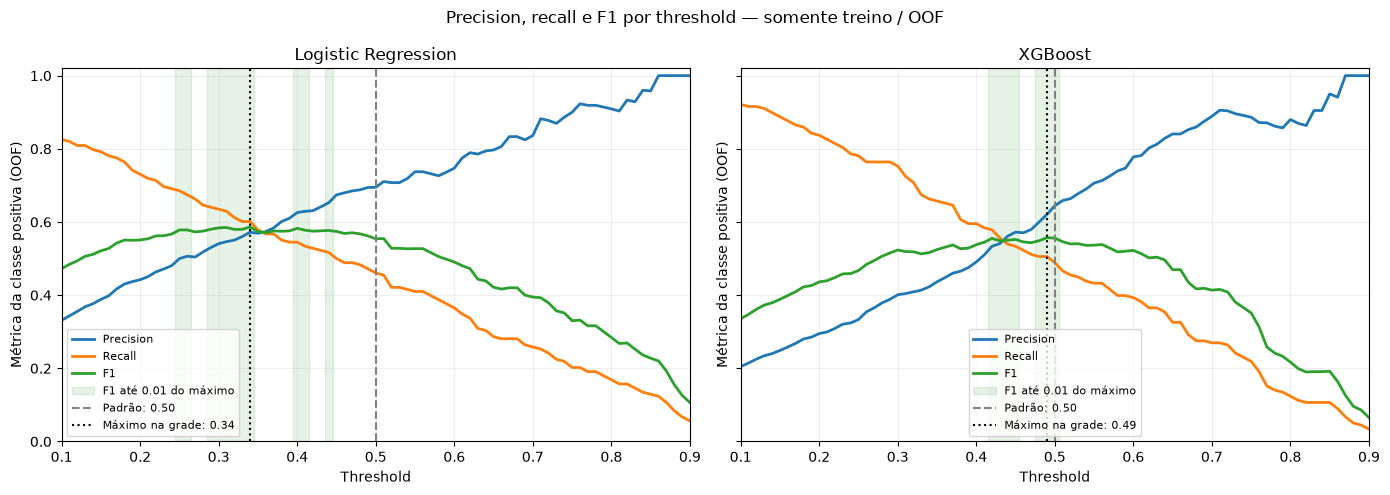

In [39]:
fig_thresholds, axes_thresholds = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model_name in zip(axes_thresholds, threshold_candidate_names):
    table = threshold_tables[model_name]
    for metric, label in [("precision", "Precision"), ("recall", "Recall"), ("f1", "F1")]:
        ax.plot(table["threshold"], table[metric], label=label, linewidth=2)
    for index, (low, high) in enumerate(good_threshold_regions[model_name]):
        ax.axvspan(low - 0.005, high + 0.005, color="green", alpha=0.10,
                   label="F1 até 0.01 do máximo" if index == 0 else None)
    ax.axvline(0.50, color="gray", linestyle="--", label="Padrão: 0.50")
    best_threshold = selected_thresholds[model_name]
    ax.axvline(best_threshold, color="black", linestyle=":", label=f"Máximo na grade: {best_threshold:.2f}")
    ax.set(title=model_name, xlabel="Threshold", xlim=(0.10, 0.90), ylim=(0, 1.02))
    ax.set_ylabel("Métrica da classe positiva (OOF)")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig_thresholds.suptitle("Precision, recall e F1 por threshold — somente treino / OOF")
fig_thresholds.tight_layout()
plt.show()

## 6.6 Interpretação e limites

A comparação deve considerar o compromisso entre precision e recall, a região de thresholds com desempenho semelhante e a complexidade. A Logística é um modelo linear mais simples; o XGBoost combina 200 árvores de profundidade máxima 2 nesta configuração e captura relações não lineares. A maior complexidade precisa ser justificada pelo objetivo e pelos custos dos erros, não apenas pelo máximo de F1 observado.

A comparação de modelos, o tuning e a otimização de threshold usam somente o treinamento e sua validação cruzada / probabilidades OOF. Os hiperparâmetros e o limiar foram selecionados usando essa mesma evidência; os scores OOF reportados são scores de seleção potencialmente otimistas, não uma estimativa independente de generalização. No protocolo implementado e documentado neste notebook, a escolha final é concluída e congelada na seção seguinte, antes da avaliação do holdout reservado.

**Leitura desta execução:**

- Na Logística, o threshold 0.34 eleva recall para 0.6011 e reduz precision para 0.5722, com F1 0.5863. As regiões com F1 até 0.01 abaixo do máximo são 0.25–0.26; 0.29–0.34; 0.40–0.41; 0.44–0.44. São intervalos separados: não devemos tratá-los como uma única faixa contínua.
- No XGBoost, 0.49 maximiza o F1 na grade, mas o ganho sobre 0.50 é somente 0.0014. As regiões próximas são 0.42–0.45; 0.48–0.50; 0.50 está incluído. Esse ganho mínimo não justifica, sozinho, preferir 0.49 ao padrão.
- Nos pontos selecionados, a Logística apresenta maior recall (0.6011) e menor precision (0.5722) que o XGBoost (0.5056 e 0.6207, respectivamente). Esse compromisso, o F1 positivo observado na seleção OOF e a maior simplicidade fundamentam a escolha da Logística para a avaliação final; o resultado posterior do holdout não participa dessa decisão.

Os máximos desta grade orientam a seleção interna. Para a avaliação final, a configuração congelada é Regressão Logística com `C=10`, `class_weight=None`, `solver="lbfgs"` e threshold `0.34`, conforme declarado a seguir. As regiões de bons thresholds mostram sensibilidade local nesta amostra, sem demonstrar robustez em dados novos ou adequação para uso externo.

In [40]:
for model_name in threshold_candidate_names:
    baseline = threshold_comparison.loc[(model_name, "Padrão")]
    optimized = threshold_comparison.loc[(model_name, "Otimizado OOF")]
    print(
        f"{model_name}: threshold 0.50 → {optimized['threshold']:.2f}; "
        f"precision {baseline['precision']:.3f} → {optimized['precision']:.3f}; "
        f"recall {baseline['recall']:.3f} → {optimized['recall']:.3f}; "
        f"F1 {baseline['f1']:.3f} → {optimized['f1']:.3f}. "
        f"Regiões próximas do máximo: {threshold_stability.loc[model_name, 'good_regions']}."
    )

# Final Holdout Evaluation

## Configuração congelada antes do acesso ao holdout

No protocolo implementado e documentado neste notebook, a seleção é encerrada com base exclusivamente no treinamento e na evidência de validação cruzada / OOF. A configuração abaixo é congelada **antes de avaliar o holdout reservado**:

```python
LogisticRegression(
    C=10,
    class_weight=None,
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
)
threshold = 0.34
```

**Motivo da escolha:** compromisso observado entre precision e recall, usando F1 da classe positiva como métrica principal na validação out-of-fold, além da simplicidade e interpretabilidade da Regressão Logística.

Será criado um novo pipeline com `make_preprocessor(..., scale_numeric=True)`: imputação por mediana e padronização das numéricas, moda e one-hot encoding das categóricas. Todas as estatísticas serão aprendidas exclusivamente em `X_train`.

Faremos um único ajuste em todo `X_train/y_train` e uma única geração de probabilidades em `X_test`. Todas as métricas, a matriz e o relatório serão derivados dessas mesmas previsões, exclusivamente com threshold **0.34**. Não haverá novo tuning, busca de threshold, comparação de outros modelos no holdout ou alteração da configuração após observar os resultados.

Após esse congelamento, o holdout serve somente para estimar o desempenho de generalização da configuração escolhida, dentro dos limites desta avaliação interna. Seus resultados não participam da seleção do modelo, dos hiperparâmetros ou do threshold.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

## Ajuste da configuração congelada

O pipeline abaixo é independente dos pipelines usados no benchmark, tuning e geração OOF. A única chamada a `fit` nesta seção usa o treinamento completo, sem incluir o holdout.

In [42]:
final_threshold = 0.34
final_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor(
        numeric_features, categorical_features, scale_numeric=True,
    )),
    ("classifier", LogisticRegression(
        C=10, class_weight=None, solver="lbfgs",
        max_iter=1000, random_state=42,
    )),
])
final_pipeline.fit(X_train, y_train)
assert final_pipeline.classes_.tolist() == [0, 1]

## Predição única no holdout

O pipeline já ajustado transforma `X_test` com as estatísticas aprendidas no treino e gera probabilidades para a classe 1. A regra congelada é `p(Yes) >= 0.34`. Não usamos `predict`, que aplicaria a decisão padrão do estimador, nem experimentamos outros thresholds.

In [43]:
final_probabilities = final_pipeline.predict_proba(X_test)[:, 1]
final_predictions = (final_probabilities >= final_threshold).astype(int)

## Métricas finais

Precision, recall e F1 referem-se explicitamente à classe positiva **1 / Attrition Yes**. Accuracy mede acertos globais. ROC-AUC e Average Precision são calculadas a partir das probabilidades, sem alterar o threshold.

In [44]:
final_metric_values = {
    "accuracy": accuracy_score(y_test, final_predictions),
    "precision": precision_score(y_test, final_predictions, average="binary", pos_label=1, zero_division=0),
    "recall": recall_score(y_test, final_predictions, average="binary", pos_label=1, zero_division=0),
    "f1": f1_score(y_test, final_predictions, average="binary", pos_label=1, zero_division=0),
    "roc_auc": roc_auc_score(y_test, final_probabilities),
    "average_precision": average_precision_score(y_test, final_probabilities, pos_label=1),
}
final_metrics = pd.DataFrame.from_dict(final_metric_values, orient="index", columns=["value"])
final_metrics.index.name = "metric"
print(final_metrics.round(4).to_string())

                    value
metric                   
accuracy           0.8478
precision          0.5273
recall             0.4915
f1                 0.5088
roc_auc            0.8098
average_precision  0.5783


## Matriz de confusão e contagens

Linhas representam a classe observada; colunas representam a previsão. TN são permanências corretamente previstas, FP são alertas incorretos de saída, FN são saídas não detectadas e TP são saídas corretamente detectadas.

               Previsto: No (0)  Previsto: Yes (1)
Real: No (0)                283                 26
Real: Yes (1)                30                 29
True Negatives (TN)     283
False Positives (FP)     26
False Negatives (FN)     30
True Positives (TP)      29


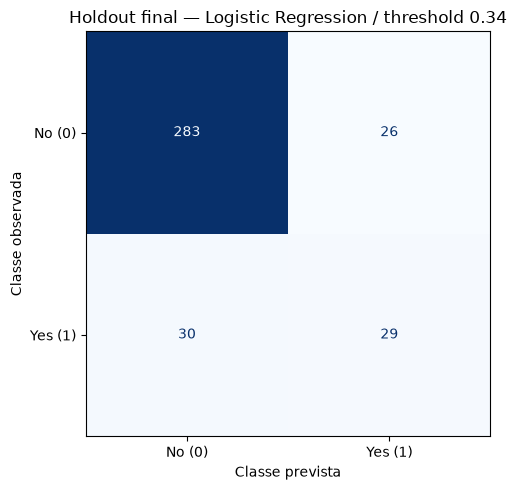

In [45]:
final_confusion_matrix = confusion_matrix(y_test, final_predictions, labels=[0, 1])
true_negatives, false_positives, false_negatives, true_positives = final_confusion_matrix.ravel()
final_confusion_counts = pd.Series({
    "True Negatives (TN)": int(true_negatives),
    "False Positives (FP)": int(false_positives),
    "False Negatives (FN)": int(false_negatives),
    "True Positives (TP)": int(true_positives),
}, name="count")
print(pd.DataFrame(
    final_confusion_matrix,
    index=["Real: No (0)", "Real: Yes (1)"],
    columns=["Previsto: No (0)", "Previsto: Yes (1)"],
).to_string())
print(final_confusion_counts.to_string())

fig_holdout, ax_holdout = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=["No (0)", "Yes (1)"],
).plot(ax=ax_holdout, cmap="Blues", values_format="d", colorbar=False)
ax_holdout.set_title("Holdout final — Logistic Regression / threshold 0.34")
ax_holdout.set_xlabel("Classe prevista")
ax_holdout.set_ylabel("Classe observada")
fig_holdout.tight_layout()
plt.show()

## Classification report

O relatório usa as mesmas classes previstas em 0.34. As médias macro e ponderada são complementares; não substituem o F1 específico da classe Yes.

In [46]:
final_classification_report = classification_report(
    y_test, final_predictions, labels=[0, 1],
    target_names=["No (0)", "Yes (1)"], digits=4, zero_division=0,
)
print(final_classification_report)

              precision    recall  f1-score   support

      No (0)     0.9042    0.9159    0.9100       309
     Yes (1)     0.5273    0.4915    0.5088        59

    accuracy                         0.8478       368
   macro avg     0.7157    0.7037    0.7094       368
weighted avg     0.8437    0.8478    0.8456       368



## Interpretação e comparação com a validação

A referência é a validação OOF da **mesma Logística e do mesmo threshold 0.34**, calculada na Parte 6. Os scores OOF orientaram a seleção e podem ser otimistas. A comparação abaixo descreve a diferença de generalização; não será usada para alterar modelo, hiperparâmetros ou threshold. As previsões representam associações aprendidas e não estabelecem causas de desligamento.

A queda observada de precision, recall e F1 entre a seleção OOF e o holdout é mantida como resultado da avaliação. Ela não reabre a seleção nem motiva alterações retrospectivas no modelo, nos hiperparâmetros ou no threshold congelados.

In [47]:
validation_reference = threshold_comparison.loc[
    ("Logistic Regression", "Otimizado OOF"), ["precision", "recall", "f1"]
]
final_generalization_comparison = pd.DataFrame({
    "Validação OOF": validation_reference,
    "Holdout final": final_metrics.loc[["precision", "recall", "f1"], "value"],
})
print(final_generalization_comparison.round(4).to_string())
print(
    f"Foram detectadas {true_positives} de {true_positives + false_negatives} saídas observadas; "
    f"{false_negatives} saídas não foram detectadas. Dos {true_positives + false_positives} alertas, "
    f"{false_positives} foram falsos positivos."
)
if final_metric_values["f1"] < validation_reference["f1"]:
    print("O F1 no holdout foi inferior ao observado na seleção OOF. Essa diferença de generalização é registrada sem reajustar a configuração olhando o teste.")
else:
    print("O F1 no holdout não foi inferior ao observado na seleção OOF. Isso não comprova superioridade estatística nem validação externa.")
print("Modelo, hiperparâmetros e threshold permanecem os congelados antes da avaliação.")

           Validação OOF  Holdout final
precision         0.5722         0.5273
recall            0.6011         0.4915
f1                0.5863         0.5088
Foram detectadas 29 de 59 saídas observadas; 30 saídas não foram detectadas. Dos 55 alertas, 26 foram falsos positivos.
O F1 no holdout foi inferior ao observado na seleção OOF. Essa diferença de generalização é registrada sem reajustar a configuração olhando o teste.
Modelo, hiperparâmetros e threshold permanecem os congelados antes da avaliação.


## Limitações da avaliação final

O dataset já havia sido explorado historicamente no projeto original. Este holdout constitui uma **avaliação interna mais rigorosa**, mas **não é validação externa independente**. A divisão utiliza a mesma base histórica; não demonstra desempenho em outra empresa, em outro período ou em uma população diferente.

A avaliação reflete uma única divisão e possui quantidade limitada de casos positivos. Os scores de validação usados para selecionar hiperparâmetros e threshold não eram estimativas independentes dessa seleção. Nenhuma dessas limitações é corrigida ajustando decisões após observar o holdout.

Esta seção encerra a avaliação da configuração congelada: nenhum outro modelo ou threshold foi avaliado no teste, e nenhuma decisão foi alterada em resposta ao resultado.